In [ ]:
from IPython.display import Image, display
import glob, os
from PIL import Image as PILImage

from google.colab import userdata
your_key = userdata.get('PIE_Colab')
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!git clone https://{your_key}@github.com/william94000schr/ATR_SAR.git

Cloning into 'ATR_SAR'...
remote: Enumerating objects: 622, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 622 (delta 90), reused 121 (delta 51), pack-reused 458 (from 1)
Receiving objects: 100% (622/622), 3.22 MiB | 11.40 MiB/s, done.
Resolving deltas: 100% (358/358), done.


In [ ]:
!cp /content/drive/MyDrive/Dataset/PIE/Détection_Coco_newClasses/SOC_17classes_coco.tar /content/
!tar -xf /content/SOC_17classes_coco.tar -C /content/ATR_SAR/data/ --strip-components=1

#!cp /content/drive/MyDrive/Dataset/PIE/Détection_Coco_newClasses/scenes.tar /content/
#!tar -xf /content/scenes.tar -C /content/ATR_SAR/data/ --strip-components=1

In [ ]:
#!cp /content/drive/MyDrive/PIE/FasterRCNN_ResNet_SOC50_results/faster_rcnn.pt /content/ATR_SAR/models
#!cp /content/drive/MyDrive/PIE/Faster_RCNN_SOC40classes_results/faster_rcnn.pt /content/ATR_SAR/models
#!cp /content/drive/MyDrive/PIE/SOC40classes_0_65_5sur5/faster_rcnn.pt /content/ATR_SAR/models
!cp /content/drive/MyDrive/PIE/SOC17classes_1_5sur5/faster_rcnn.pt /content/ATR_SAR/models

In [ ]:
%cd ATR_SAR/src/

/content/ATR_SAR/src


In [ ]:
import sys, os, random, torch
sys.path.append(".")
from predict import load_model, load_class_names, run_on_image
from dataset import SAR_ATR_Dataset
from transforms import CocoToFasterRCNN
from PIL import Image
from IPython.display import display
import yaml
with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)
from pathlib import Path
project_root = Path("../")
img_dir  = project_root / config["data"]["images"]["test"]["img_dir"]
ann_file = project_root / config["data"]["annotations"]["test"]["ann_file"]

dataset = SAR_ATR_Dataset(root=str(img_dir), annFile=str(ann_file), transforms=CocoToFasterRCNN())
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model       = load_model(device)
class_names = load_class_names()

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 164MB/s]


Model loaded — 18 classes (including background)


Ground truth:
  - SUV
Predictions:
  - Car | score: 0.99


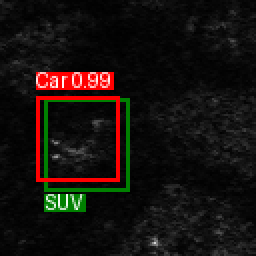

In [ ]:
idx        = random.randint(0, len(dataset) - 1)
_, target  = dataset[idx]

image_info = dataset.coco.loadImgs(dataset.ids[idx])[0]
image_path = os.path.join(dataset.root, image_info['file_name'])
ground_truth = {'boxes': target['boxes'], 'labels': target['labels']}

save_path = run_on_image(image_path, model, device, threshold=0.5, ground_truth=ground_truth, class_names=class_names)
display(Image.open(save_path).resize((256, 256), Image.NEAREST))


Ground truth:
  - Car
Predictions:
  - Car | score: 1.00


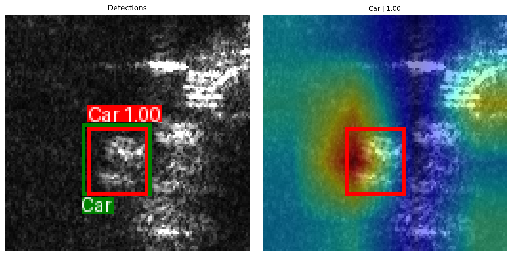

In [ ]:
idx        = random.randint(0, len(dataset) - 1)
_, target  = dataset[idx]

image_info = dataset.coco.loadImgs(dataset.ids[idx])[0]
image_path = os.path.join(dataset.root, image_info['file_name'])
ground_truth = {'boxes': target['boxes'], 'labels': target['labels']}

save_path = run_on_image(image_path, model, device, threshold=0.5, explainability=True, ground_truth=ground_truth, class_names=class_names)
display(Image.open(save_path).resize((512, 256), Image.NEAREST))

## Images aléatoires

In [ ]:
!wget https://picsum.photos/500 -O /content/random.jpg

--2026-03-06 12:38:34--  https://picsum.photos/500
Resolving picsum.photos (picsum.photos)... 104.26.4.30, 172.67.74.163, 104.26.5.30, ...
Connecting to picsum.photos (picsum.photos)|104.26.4.30|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/648/500/500.jpg?hmac=9vcapc2omx-gm8nbEzhj1Tk2McGAqgZqacSfNFXYV_c [following]
--2026-03-06 12:38:34--  https://fastly.picsum.photos/id/648/500/500.jpg?hmac=9vcapc2omx-gm8nbEzhj1Tk2McGAqgZqacSfNFXYV_c
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46755 (46K) [image/jpeg]
Saving to: ‘/content/random.jpg’

/content/random.jpg 100%[===================>]  45.66K  --.-KB/s    in 0.001s  

2026-03-06 12:38:34 (35.7 MB/s) - ‘/content/random.jpg’ saved [46755/46755]



Model loaded — 18 classes (including background)
No detection above threshold.


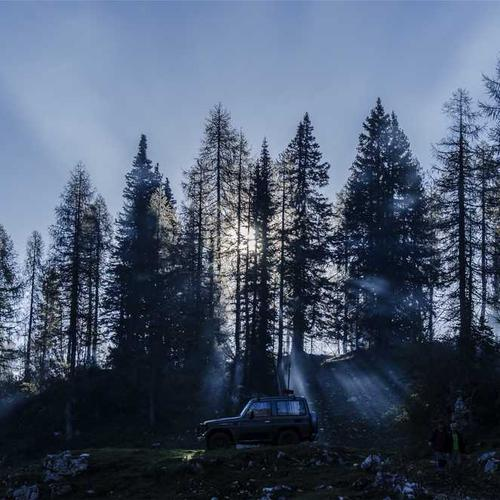

In [ ]:
!python predict.py --image_path "/content/random.jpg" --threshold 0.3
display(Image.open("../outputs/predictions/pred_random.png"))

## scene

Model loaded — 18 classes (including background)
Predictions:
  - Medium Car | score: 1.00


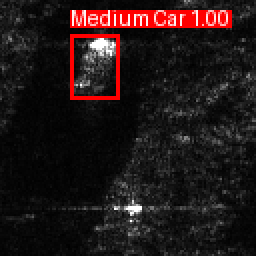

In [ ]:
#!python predict.py --image_path "/content/scene_0034.png" --threshold 0.5
!python predict.py --image_path "/content/KU_HH_15_25_948807.tif" --threshold 0.5
img = PILImage.open("../outputs/predictions/pred_KU_HH_15_25_948807.png")
img_resized = img.resize((256, 256), PILImage.NEAREST)
display(img_resized)